# Data Overview

## Import

In [ ]:
import pandas as pd
import numpy as np
import datetime
import joblib
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from imblearn.over_sampling import SMOTE
from collections import Counter

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score,confusion_matrix,ConfusionMatrixDisplay,roc_curve, auc
from xgboost import XGBClassifier

## Read Dataset

In [ ]:
# Read from google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
lending = pd.read_excel('/content/drive/MyDrive/DA-DS/Materi SQL/CAPSTONE PROJECT/klasifikasi bank .xlsx')

In [ ]:
lending

,Unnamed: 0,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_length,home_ownership,...,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,0,5000,5000,4975.0,36 months,10.65,162.87,B,10+ years,RENT,...,0.00,0.00,Jan-15,171.62,Jan-16,0.0,0.0,NaN,NaN,NaN
1,1,2500,2500,2500.0,60 months,15.27,59.83,C,< 1 year,RENT,...,117.08,1.11,Apr-13,119.66,Sep-13,0.0,0.0,NaN,NaN,NaN
2,2,2400,2400,2400.0,36 months,15.96,84.33,C,10+ years,RENT,...,0.00,0.00,Jun-14,649.91,Jan-16,0.0,0.0,NaN,NaN,NaN
3,3,10000,10000,10000.0,36 months,13.49,339.31,C,10+ years,RENT,...,0.00,0.00,Jan-15,357.48,Jan-15,0.0,0.0,NaN,NaN,NaN
4,4,3000,3000,3000.0,60 months,12.69,67.79,B,1 year,RENT,...,0.00,0.00,Jan-16,67.79,Jan-16,0.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,466280,18400,18400,18400.0,60 months,14.47,432.64,C,4 years,MORTGAGE,...,0.00,0.00,Jan-16,432.64,Jan-16,0.0,0.0,0.0,294998.0,29900.0
466281,466281,22000,22000,22000.0,60 months,19.97,582.50,D,10+ years,MORTGAGE,...,0.00,0.00,Dec-14,17.50,Jan-16,0.0,0.0,0.0,221830.0,39400.0
466282,466282,20700,20700,20700.0,60 months,16.99,514.34,D,7 years,MORTGAGE,...,0.00,0.00,Jan-16,514.34,Dec-15,0.0,0.0,0.0,73598.0,13100.0
466283,466283,2000,2000,2000.0,36 months,7.90,62.59,A,3 years,OWN,...,0.00,0.00,Dec-14,1500.68,Apr-15,0.0,0.0,0.0,591610.0,53100.0


In [ ]:
lending.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Unnamed: 0                  466285 non-null  int64  
 1   loan_amnt                   466285 non-null  int64  
 2   funded_amnt                 466285 non-null  int64  
 3   funded_amnt_inv             466285 non-null  float64
 4   term                        466285 non-null  object 
 5   int_rate                    466285 non-null  float64
 6   installment                 466285 non-null  float64
 7   grade                       466285 non-null  object 
 8   emp_length                  445277 non-null  object 
 9   home_ownership              466285 non-null  object 
 10  annual_inc                  466281 non-null  float64
 11  verification_status         466285 non-null  object 
 12  issue_d                     466285 non-null  object 
 13  loan_status   

## Check data

In [ ]:
lending.describe(include='all')

,Unnamed: 0,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_length,home_ownership,...,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
count,466285.000000,466285.000000,466285.000000,466285.000000,466285,466285.000000,466285.000000,466285,445277,466285,...,466285.000000,466285.000000,465909,466285.000000,466243,466140.000000,466256.000000,3.960090e+05,3.960090e+05,3.960090e+05
unique,NaN,NaN,NaN,NaN,2,NaN,NaN,7,11,6,...,NaN,NaN,98,NaN,103,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,36 months,NaN,NaN,B,10+ years,MORTGAGE,...,NaN,NaN,Jan-16,NaN,Jan-16,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,337953,NaN,NaN,136929,150049,235875,...,NaN,NaN,179620,NaN,327699,NaN,NaN,NaN,NaN,NaN
mean,233142.000000,14317.277577,14291.801044,14222.329888,NaN,13.829236,432.061201,NaN,NaN,NaN,...,85.344211,8.961534,NaN,3123.913796,NaN,0.009085,0.004002,1.919135e+02,1.388017e+05,3.037909e+04
std,134605.029472,8286.509164,8274.371300,8297.637788,NaN,4.357587,243.485550,NaN,NaN,NaN,...,552.216084,85.491437,NaN,5554.737393,NaN,0.108648,0.068637,1.463021e+04,1.521147e+05,3.724713e+04
min,0.000000,500.000000,500.000000,0.000000,NaN,5.420000,15.670000,NaN,NaN,NaN,...,0.000000,0.000000,NaN,0.000000,NaN,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,116571.000000,8000.000000,8000.000000,8000.000000,NaN,10.990000,256.690000,NaN,NaN,NaN,...,0.000000,0.000000,NaN,312.620000,NaN,0.000000,0.000000,0.000000e+00,2.861800e+04,1.350000e+04
50%,233142.000000,12000.000000,12000.000000,12000.000000,NaN,13.660000,379.890000,NaN,NaN,NaN,...,0.000000,0.000000,NaN,545.960000,NaN,0.000000,0.000000,0.000000e+00,8.153900e+04,2.280000e+04
75%,349713.000000,20000.000000,20000.000000,19950.000000,NaN,16.490000,566.580000,NaN,NaN,NaN,...,0.000000,0.000000,NaN,3187.510000,NaN,0.000000,0.000000,0.000000e+00,2.089530e+05,3.790000e+04


In [ ]:
lending.duplicated().sum()

np.int64(0)

In [ ]:
lending.isnull().sum()

,0
Unnamed: 0,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
term,0
int_rate,0
installment,0
grade,0
emp_length,21008
home_ownership,0


In [ ]:
lending['loan_status'].value_counts()

,count
loan_status,
Current,224226
Fully Paid,184739
Charged Off,42475
Late (31-120 days),6900
In Grace Period,3146
Does not meet the credit policy. Status:Fully Paid,1988
Late (16-30 days),1218
Default,832
Does not meet the credit policy. Status:Charged Off,761


## Data executions

### **Hapus 3 kolom terakhir**

In [ ]:
# hapus 3 kolom terakhir
lending.drop(lending.columns[-3:], axis=1, inplace=True)
lending.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Unnamed: 0                  466285 non-null  int64  
 1   loan_amnt                   466285 non-null  int64  
 2   funded_amnt                 466285 non-null  int64  
 3   funded_amnt_inv             466285 non-null  float64
 4   term                        466285 non-null  object 
 5   int_rate                    466285 non-null  float64
 6   installment                 466285 non-null  float64
 7   grade                       466285 non-null  object 
 8   emp_length                  445277 non-null  object 
 9   home_ownership              466285 non-null  object 
 10  annual_inc                  466281 non-null  float64
 11  verification_status         466285 non-null  object 
 12  issue_d                     466285 non-null  object 
 13  loan_status   

### **mengubah nama Unnamed --> lend_id**

In [ ]:
# mengubah kolom name Unnamed ke --> lend_id
lending.rename(columns={'Unnamed: 0':'lend_id'}, inplace=True)
lending.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   lend_id                     466285 non-null  int64  
 1   loan_amnt                   466285 non-null  int64  
 2   funded_amnt                 466285 non-null  int64  
 3   funded_amnt_inv             466285 non-null  float64
 4   term                        466285 non-null  object 
 5   int_rate                    466285 non-null  float64
 6   installment                 466285 non-null  float64
 7   grade                       466285 non-null  object 
 8   emp_length                  445277 non-null  object 
 9   home_ownership              466285 non-null  object 
 10  annual_inc                  466281 non-null  float64
 11  verification_status         466285 non-null  object 
 12  issue_d                     466285 non-null  object 
 13  loan_status   

### **mengubah nama term --> term_months, menghapus kata  months, mengganti tipe data object ke int**

In [ ]:
# Menghapus kata months di term
# mengganti nama kolom term --> term_months
lending['term'] = lending['term'].str.replace(' months', '')
lending['term'] = lending['term'].astype(int)
lending.rename(columns={'term':'term_months'}, inplace=True)
lending.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   lend_id                     466285 non-null  int64  
 1   loan_amnt                   466285 non-null  int64  
 2   funded_amnt                 466285 non-null  int64  
 3   funded_amnt_inv             466285 non-null  float64
 4   term_months                 466285 non-null  int64  
 5   int_rate                    466285 non-null  float64
 6   installment                 466285 non-null  float64
 7   grade                       466285 non-null  object 
 8   emp_length                  445277 non-null  object 
 9   home_ownership              466285 non-null  object 
 10  annual_inc                  466281 non-null  float64
 11  verification_status         466285 non-null  object 
 12  issue_d                     466285 non-null  object 
 13  loan_status   

### **Drop value annual_inc**

In [ ]:
# hapus 4 missing value annual_inc
lending.dropna(subset=['annual_inc'], inplace=True)
lending.info()

<class 'pandas.core.frame.DataFrame'>
Index: 466281 entries, 0 to 466284
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   lend_id                     466281 non-null  int64  
 1   loan_amnt                   466281 non-null  int64  
 2   funded_amnt                 466281 non-null  int64  
 3   funded_amnt_inv             466281 non-null  float64
 4   term_months                 466281 non-null  int64  
 5   int_rate                    466281 non-null  float64
 6   installment                 466281 non-null  float64
 7   grade                       466281 non-null  object 
 8   emp_length                  445273 non-null  object 
 9   home_ownership              466281 non-null  object 
 10  annual_inc                  466281 non-null  float64
 11  verification_status         466281 non-null  object 
 12  issue_d                     466281 non-null  object 
 13  loan_status        

### **mengubah nama emp_length --> emp_length_years, menghapus kata  years,year, mengganti tipe data object ke Int64**

In [ ]:
# Menghapus kata 'years' dan 'year' dan hapus simbol di emp_length kemudian ubah ke Int

lending['emp_length'] = (
    lending['emp_length']
    .str.replace('years', '', case=False, regex=False)
    .str.replace('year', '', case=False, regex=False)
    .str.replace('+', '', regex=False)
    .str.replace('< 1', '0', regex=False) # < 1 year konversi ke angka 0
    .str.strip()
)

In [ ]:
# rename emp_length -- emp_length_years
lending.rename(columns={'emp_length':'emp_length_years'}, inplace=True)
lending.info()

<class 'pandas.core.frame.DataFrame'>
Index: 466281 entries, 0 to 466284
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   lend_id                     466281 non-null  int64  
 1   loan_amnt                   466281 non-null  int64  
 2   funded_amnt                 466281 non-null  int64  
 3   funded_amnt_inv             466281 non-null  float64
 4   term_months                 466281 non-null  int64  
 5   int_rate                    466281 non-null  float64
 6   installment                 466281 non-null  float64
 7   grade                       466281 non-null  object 
 8   emp_length_years            445273 non-null  object 
 9   home_ownership              466281 non-null  object 
 10  annual_inc                  466281 non-null  float64
 11  verification_status         466281 non-null  object 
 12  issue_d                     466281 non-null  object 
 13  loan_status        

**Menggunakan knn untuk mengisi Missing value lama bekerja**

In [ ]:
# mengubah tipe data ke float agar NaN bisa dibaca sistem KNN
lending['emp_length_years'] = lending['emp_length_years'].astype('float64')

#  menentukan fitur dalam satu baris yang mau dibandingkan
features = ['emp_length_years', 'loan_amnt', 'annual_inc', 'dti', 'installment']

#  mengambil sampel referensi (tetangga) dan baris yang kosong (Hanya untuk komputasi KNN)
df_clean_rows = lending[lending['emp_length_years'].notna()][features]
df_missing_rows = lending[lending['emp_length_years'].isna()][features]

# menjalankan algoritma KNN
imputer = KNNImputer(n_neighbors=5)
imputer.fit(df_clean_rows)
imputed_values = imputer.transform(df_missing_rows)

#  memasukkan KEMBALI HANYA KE BARIS YANG TADINYA KOSONG DI KOLOM ASLI
# Sifatnya menimpa (overwrite) nilai NaN, tidak membuat kolom baru
lending.loc[lending['emp_length_years'].isna(), 'emp_length_years'] = np.round(imputed_values[:, 0])

# mengembalikan tipe data kolom asli ke int agar rapi menjadi bilangan bulat
lending['emp_length_years'] = lending['emp_length_years'].astype('int')

# Validasi Akhir:
print(f"Jumlah missing value di kolom emp_length_years sekarang: {lending['emp_length_years'].isna().sum()}")

Jumlah missing value di kolom emp_length_years sekarang: 0


Menggunakan knn karena dia akan melihat data tetangganya (melihat pola dari data tetangganya)

### **revol_bal = jumlah uang pinjaman yang telah digunakan dari perusahaan peminjaman lain. revol_util = persentase dari revol_bal**

In [ ]:
# mengubah value 0 pada revol_util, jika nilai revol_bal = 0
lending.loc[lending['revol_bal'] == 0, 'revol_util'] = 0

In [ ]:
lending.isna().sum()

,0
lend_id,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
term_months,0
int_rate,0
installment,0
grade,0
emp_length_years,0
home_ownership,0


In [ ]:
# dari revol_util masih ada 66 data yang missing

lending.loc[
    lending['revol_util'].isna(),
    ['revol_bal', 'revol_util']
].head(20)

,revol_bal,revol_util
37609,49238,NaN
41175,290291,NaN
49606,1545,NaN
52145,2028,NaN
78172,15304,NaN
79428,1960,NaN
91962,58,NaN
97987,1104,NaN
98388,5330,NaN
99411,42546,NaN


In [ ]:
# Mengisi kolom kosong revol_util menggunakan median
lending['revol_util'].fillna(lending['revol_util'].median(), inplace=True)

### **delinq_2yrs,earliest_cr_line, inq_last_6mths,open_acc,pub_rec, total_acc,acc_now_delinq**

In [ ]:
# kolom yang ku curigai saling berkaitan jumlh missing value =25
cols_to_check = ['delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec', 'total_acc', 'acc_now_delinq']

# Cek apakah missing values pada baris tersebut terjadi di SEMUA kolom di atas secara bersamaan
rows_missing_all = lending[lending[cols_to_check].isna().all(axis=1)]

print(f"Jumlah baris yang missing di semua kolom tersebut: {len(rows_missing_all)}")

Jumlah baris yang missing di semua kolom tersebut: 25


In [ ]:
# drop missing value dari 7 kolom
cols_to_clean = [
    'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
    'open_acc', 'pub_rec', 'total_acc', 'acc_now_delinq'
]
lending = lending.dropna(subset=cols_to_clean)

# Validasi ulang untuk memastikan missing values di kolom tersebut sudah 0
print("Jumlah missing values setelah di-drop:")
print(lending[cols_to_clean].isna().sum())
print(f"\nUkuran dataset sekarang: {lending.shape}")

Jumlah missing values setelah di-drop:
delinq_2yrs         0
earliest_cr_line    0
inq_last_6mths      0
open_acc            0
pub_rec             0
total_acc           0
acc_now_delinq      0
dtype: int64

Ukuran dataset sekarang: (466256, 40)


### **mengisi collections_12_mths_ex_med = 0**

In [ ]:
lending['collections_12_mths_ex_med'].value_counts()

,count
collections_12_mths_ex_med,
0.0,462226
1.0,3665
2.0,219
3.0,19
4.0,7
6.0,1
16.0,1
20.0,1
5.0,1


In [ ]:
# karena mosly jml mayoritas 0
# collections_12_mths_ex_med = berapa kali nasabah mendapatkan penagihan dalam 12 bulan terakhir (di luar medis)
lending['collections_12_mths_ex_med'] = lending['collections_12_mths_ex_med'].fillna(0)

### **UBAH TIPE DATA YANG BERUPA TANGGAL : last_pymnt_d & last_credit_pull_d, earliest_cr_line**



In [ ]:
lending['earliest_cr_line'] = pd.to_datetime(
    lending['earliest_cr_line'],
    format='%b-%y',
    errors='coerce'
)
lending['issue_d'] = pd.to_datetime(
    lending['issue_d'],
    format='%b-%y',
    errors='coerce'
)

lending['last_pymnt_d'] = pd.to_datetime(
    lending['last_pymnt_d'],
    format='%b-%y',
    errors='coerce'
)

lending['last_credit_pull_d'] = pd.to_datetime(
    lending['last_credit_pull_d'],
    format='%b-%y',
    errors='coerce'
)

In [ ]:
# isi value last_pymnt_d dan last_credit_pull_d dengan tanggal maximum
lending['last_pymnt_d'].fillna(lending['last_pymnt_d'].max(), inplace=True)
lending['last_credit_pull_d'].fillna(lending['last_credit_pull_d'].max(), inplace=True)

### **lower case home_ownership, verification_status, addr_state**

In [ ]:
# lower case value dari home_ownership
lending['home_ownership'] = lending['home_ownership'].str.lower()

# lower case dari verification_status
lending['verification_status'] = lending['verification_status'].str.lower()

# lower case addr_state
lending['addr_state'] = lending['addr_state'].str.lower()

### **menghapus "_" di kolom purpose**

In [ ]:
# hapus _ kolom purpose
lending['purpose'] = lending['purpose'].str.replace('_', ' ', regex=False).str.title()

In [ ]:
# lower case purpose
lending['purpose'] = lending['purpose'].str.lower()

In [ ]:
lending['purpose'].head()

,purpose
0,credit card
1,car
2,small business
3,other
4,other


### **check outlier**

In [ ]:
outlier_cols = ['annual_inc', 'loan_amnt']

for col in outlier_cols:
    Q1 = lending[col].quantile(0.25)
    Q3 = lending[col].quantile(0.75)
    IQR = Q3 - Q1

    # batas bawah dan batas atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # jumlah outlier
    outliers = lending[(lending[col] < lower_bound) | (lending[col] > upper_bound)]
    percentage = (len(outliers) / len(lending)) * 100

    print(f"\nKolom {col}:")
    print(f"Batas Bawah Wajar: {lower_bound}")
    print(f"Batas Atas Wajar : {upper_bound}")
    print(f"Nilai Maksimum   : {lending[col].max()}")
    print(f"Jumlah Outlier   : {len(outliers)} baris ({percentage:.2f}%)")


Kolom annual_inc:
Batas Bawah Wajar: -20927.25
Batas Atas Wajar : 154878.75
Nilai Maksimum   : 7500000.0
Jumlah Outlier   : 19897 baris (4.27%)

Kolom loan_amnt:
Batas Bawah Wajar: -10000.0
Batas Atas Wajar : 38000.0
Nilai Maksimum   : 35000
Jumlah Outlier   : 0 baris (0.00%)


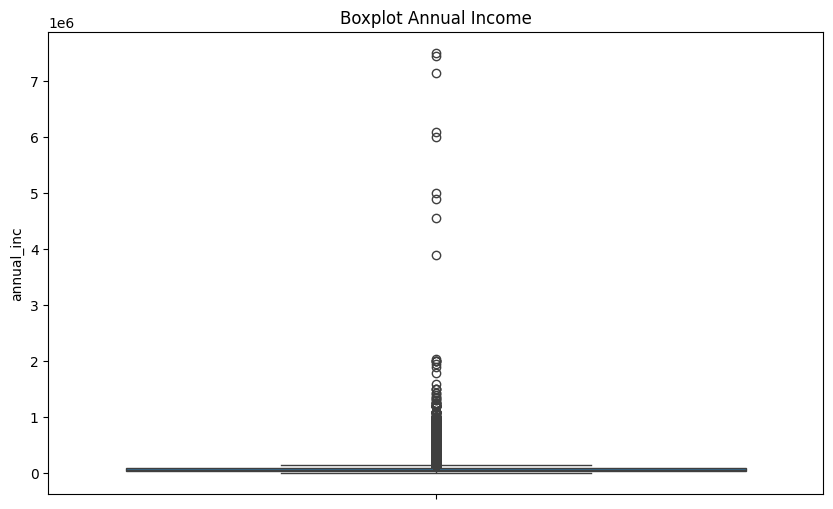

In [ ]:
# visualisasi outlier annual_inc
plt.figure(figsize=(10, 6))
sns.boxplot(y=lending['annual_inc'])
plt.title('Boxplot Annual Income')
plt.show()

## **Mengkategorikan kolom LOAN STATUS**

In [ ]:
loan_mapping = {
    # Kelompok GOOD LOAN (Label 0)
    'Fully Paid': 0,
    'Current': 0,
    'In Grace Period': 0,
    'Late (16-30 days)': 0,
    'Does not meet the credit policy. Status:Fully Paid': 0,

    # Kelompok BAD LOAN (Label 1)
    'Charged Off': 1,
    'Default': 1,
    'Late (31-120 days)': 1,
    'Does not meet the credit policy. Status:Charged Off': 1
}
lending['bad_loan'] = lending['loan_status'].map(loan_mapping)
lending['bad_loan'] = lending['bad_loan'].astype('Int64')

In [ ]:
print("\n--- Prosentase Good vs Bad Loan ---")
print(lending['bad_loan'].value_counts(normalize=True) * 100)


--- Prosentase Good vs Bad Loan ---
bad_loan
0    89.06931
1    10.93069
Name: proportion, dtype: Float64


## Dataset Clean

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
lending_clean = lending.copy()
lending_clean.head()

,lend_id,loan_amnt,funded_amnt,funded_amnt_inv,term_months,int_rate,installment,grade,emp_length_years,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,bad_loan
0,0,5000,5000,4975.0,36,10.65,162.87,B,10,rent,24000.0,verified,2011-12-01,Fully Paid,credit card,az,27.65,0.0,1985-01-01,1.0,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,2015-01-01,171.62,2016-01-01,0.0,0.0,0
1,1,2500,2500,2500.0,60,15.27,59.83,C,0,rent,30000.0,source verified,2011-12-01,Charged Off,car,ga,1.00,0.0,1999-04-01,5.0,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,2013-04-01,119.66,2013-09-01,0.0,0.0,1
2,2,2400,2400,2400.0,36,15.96,84.33,C,10,rent,12252.0,not verified,2011-12-01,Fully Paid,small business,il,8.72,0.0,2001-11-01,2.0,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,2014-06-01,649.91,2016-01-01,0.0,0.0,0
3,3,10000,10000,10000.0,36,13.49,339.31,C,10,rent,49200.0,source verified,2011-12-01,Fully Paid,other,ca,20.00,0.0,1996-02-01,1.0,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,2015-01-01,357.48,2015-01-01,0.0,0.0,0
4,4,3000,3000,3000.0,60,12.69,67.79,B,1,rent,80000.0,source verified,2011-12-01,Current,other,or,17.94,0.0,1996-01-01,0.0,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,2016-01-01,67.79,2016-01-01,0.0,0.0,0


In [ ]:
lending_clean.describe(include='all')

,lend_id,loan_amnt,funded_amnt,funded_amnt_inv,term_months,int_rate,installment,grade,emp_length_years,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,bad_loan
count,466256.000000,466256.000000,466256.000000,466256.000000,466256.000000,466256.000000,466256.000000,466256,466256.000000,466256,4.662560e+05,466256,466256,466256,466256,466256,466256.000000,466256.000000,466256,466256.000000,466256.000000,466256.000000,4.662560e+05,466256.000000,466256.000000,466256,466256.000000,466256.000000,466256.000000,466256.000000,466256.000000,466256.000000,466256.000000,466256.000000,466256.000000,466256,466256.000000,466256,466256.000000,466256.000000,466256.0
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN,6,NaN,3,NaN,9,14,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B,NaN,mortgage,NaN,verified,NaN,Current,debt consolidation,ca,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,136919,NaN,235868,NaN,168055,NaN,224226,274194,71450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,302976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
mean,233153.856830,14317.925292,14292.451733,14223.162366,42.605744,13.829513,432.080469,NaN,5.967531,NaN,7.327749e+04,NaN,2013-08-23 18:56:11.085412608,NaN,NaN,NaN,17.219347,0.284678,1997-12-16 11:57:43.058920320,0.804745,11.187069,0.160564,1.623121e+04,56.142602,25.064430,NaN,4410.336638,4408.726453,11541.137432,11470.547736,8866.341344,2588.809240,0.649769,85.337081,8.957759,2015-04-23 12:58:18.946501120,3124.095683,2015-08-30 20:00:42.867437568,0.009083,0.004002,0.109307
min,0.000000,500.000000,500.000000,0.000000,36.000000,5.420000,15.670000,NaN,0.000000,NaN,1.896000e+03,NaN,2007-06-01 00:00:00,NaN,NaN,NaN,0.000000,0.000000,1969-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2007-12-01 00:00:00,0.000000,2007-05-01 00:00:00,0.000000,0.000000,0.0
25%,116592.750000,8000.000000,8000.000000,8000.000000,36.000000,10.990000,256.760000,NaN,3.000000,NaN,4.500000e+04,NaN,2013-03-01 00:00:00,NaN,NaN,NaN,11.360000,0.000000,1994-03-01 00:00:00,0.000000,8.000000,0.000000,6.414000e+03,39.200000,17.000000,NaN,0.000000,0.000000,5552.615000,5499.480000,3708.920000,957.470000,0.000000,0.000000,0.000000,2015-01-01 00:00:00,312.620000,2015-11-01 00:00:00,0.000000,0.000000,0.0
50%,233156.500000,12000.000000,12000.000000,12000.000000,36.000000,13.660000,379.915000,NaN,6.000000,NaN,6.300000e+04,NaN,2014-01-01 00:00:00,NaN,NaN,NaN,16.870000,0.000000,1999-03-01 00:00:00,0.000000,10.000000,0.000000,1.176500e+04,57.500000,23.000000,NaN,443.190000,442.750000,9419.880000,9355.970000,6817.890000,1819.015000,0.000000,0.000000,0.000000,2015-12-01 00:00:00,545.960000,2016-01-01 00:00:00,0.000000,0.000000,0.0
75%,349720.250000,20000.000000,20000.000000,19950.000000,60.000000,16.490000,566.620000,NaN,10.000000,NaN,8.895150e+04,NaN,2014-07-01 00:00:00,NaN,NaN,NaN,22.780000,0.000000,2002-09-01 00:00:00,1.000000,14.000000,0.000000,2.033300e+04,74.700000,32.000000,NaN,7341.995000,7338.390000,15308.735000,15232.057500,12000.000000,3304.652500,0.000000,0.000000,0.000000,2016-01-01 00:00:00,3188.432500,2016-01-01 00:00:00,0.000000,0.000000,0.0
max,466284.000000,35000.000000,35000.000000,35000.000000,60.000000,26.060000,1409.990000,NaN,10.000000,NaN,7.500000e+06,NaN,2014-12-01 00:00:00,NaN,NaN,NaN,39.990000,29.000000,2068-12-01 00:00:00,33.000000,84.000000,63.000000,2.568995e+06,892.300000,156.000000,NaN,3216

In [ ]:
# export lending_clean
lending_clean.to_excel('/content/drive/MyDrive/DA-DS/Materi SQL/CAPSTONE PROJECT/lending_clean.xlsx', index=False)

# Connect To SQL

In [ ]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "your username"
password = quote_plus("your password")
host = "your host name"
port = "your port"
database = "postgres"

DATABASE_URL = (
    f"postgresql://{username}:{password}@{host}:{port}/{database}"
)

engine = create_engine(DATABASE_URL)

In [ ]:
lending.to_sql("lending_clean",engine,if_exists="replace",index=False)

# EDA

In [ ]:
lending_clean.head()

,lend_id,loan_amnt,funded_amnt,funded_amnt_inv,term_months,int_rate,installment,grade,emp_length_years,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,bad_loan
0,0,5000,5000,4975.0,36,10.65,162.87,B,10,rent,24000.0,verified,2011-12-01,Fully Paid,credit card,az,27.65,0.0,1985-01-01,1.0,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,2015-01-01,171.62,2016-01-01,0.0,0.0,0
1,1,2500,2500,2500.0,60,15.27,59.83,C,0,rent,30000.0,source verified,2011-12-01,Charged Off,car,ga,1.00,0.0,1999-04-01,5.0,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,2013-04-01,119.66,2013-09-01,0.0,0.0,1
2,2,2400,2400,2400.0,36,15.96,84.33,C,10,rent,12252.0,not verified,2011-12-01,Fully Paid,small business,il,8.72,0.0,2001-11-01,2.0,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,2014-06-01,649.91,2016-01-01,0.0,0.0,0
3,3,10000,10000,10000.0,36,13.49,339.31,C,10,rent,49200.0,source verified,2011-12-01,Fully Paid,other,ca,20.00,0.0,1996-02-01,1.0,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,2015-01-01,357.48,2015-01-01,0.0,0.0,0
4,4,3000,3000,3000.0,60,12.69,67.79,B,1,rent,80000.0,source verified,2011-12-01,Current,other,or,17.94,0.0,1996-01-01,0.0,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,2016-01-01,67.79,2016-01-01,0.0,0.0,0


In [ ]:
lending_clean.groupby(by='grade')['bad_loan'].value_counts()

grade  bad_loan
A      0            71960
       1             2896
B      0           126161
       1            10758
C      0           110903
       1            14384
D      0            65040
       1            11847
E      0            28792
       1             6964
F      0            10037
       1             3192
G      0             2398
       1              924
Name: count, dtype: Int64

grade A --> risiko aman (%rendah)
grade G --> risiko gagal bayar tinggi (% tinggi), bunga nya tinggi <--> perusahaan untung

jadi, di kelas G : 3,322 orang, perusahaan memberi bunga tinggi (High risk high return) harapannya semua orang aktif bayar --> perusahaan untung. TAPI 924 ini dinyatakan gagal bayar (membuat perusahaan rugi)

# **Leakage and unused cols**
kolom-kolom itu adalah informasi dari masa depan yang belum lahir saat proses penyeleksian nasabah baru dilakukan.

In [ ]:
leakage_and_unused_cols = [
   'lend_id', 'loan_status',
    'earliest_cr_line', 'last_pymnt_d', 'last_credit_pull_d', 'issue_d',
    'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee',
    'last_pymnt_amnt',
    'funded_amnt', 'funded_amnt_inv'
]

# drop kolom diatas
df_model = lending_clean.drop(columns=leakage_and_unused_cols)
print(f"Jumlah kolom tersisa untuk masuk ke Train-Test Split: {df_model.shape[1]} kolom")

Jumlah kolom tersisa untuk masuk ke Train-Test Split: 23 kolom


# Split Train Test

In [ ]:
X = df_model.drop(columns='bad_loan')
y = df_model['bad_loan']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")

Ukuran X_train: (373004, 22)
Ukuran X_test: (93252, 22)


In [ ]:
# salin data X_train dan X_test agar data aslinya tidak rusak
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Feature Encode

In [ ]:
df_model.head()

,loan_amnt,term_months,int_rate,installment,grade,emp_length_years,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,acc_now_delinq,bad_loan
0,5000,36,10.65,162.87,B,10,rent,24000.0,verified,credit card,az,27.65,0.0,1.0,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,0
1,2500,60,15.27,59.83,C,0,rent,30000.0,source verified,car,ga,1.00,0.0,5.0,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1
2,2400,36,15.96,84.33,C,10,rent,12252.0,not verified,small business,il,8.72,0.0,2.0,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,0
3,10000,36,13.49,339.31,C,10,rent,49200.0,source verified,other,ca,20.00,0.0,1.0,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,0
4,3000,60,12.69,67.79,B,1,rent,80000.0,source verified,other,or,17.94,0.0,0.0,15.0,0.0,27783,53.9,38.0,f,0.0,0.0,0


**.fit() untuk encoder hanya boleh dilakukan pada X_train. Untuk X_test, kita hanya boleh menggunakan .transform()**

In [ ]:
# label : grade
grade_order = [['A', 'B', 'C', 'D', 'E', 'F', 'G']]
ord_encoder = OrdinalEncoder(categories=grade_order, handle_unknown='use_encoded_value', unknown_value=-1)

# Fit dan transform di Train, transform saja di Test
X_train_encoded['grade'] = ord_encoder.fit_transform(X_train[['grade']])
X_test_encoded['grade'] = ord_encoder.transform(X_test[['grade']])

In [ ]:
# encode ohe : home_ownership, verification_status, purpose, initial_list_status, addr_state
ohe_cols = ['home_ownership', 'verification_status', 'purpose', 'initial_list_status', 'addr_state']

# handle_unknown='ignore' agar tidak error jika ada kategori baru di X_test
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit & Transform di Train
ohe_train_array = ohe.fit_transform(X_train_encoded[ohe_cols])
ohe_feature_names = ohe.get_feature_names_out(ohe_cols)
df_ohe_train = pd.DataFrame(ohe_train_array, columns=ohe_feature_names, index=X_train_encoded.index)

# Hanya Transform di Test
ohe_test_array = ohe.transform(X_test_encoded[ohe_cols])
df_ohe_test = pd.DataFrame(ohe_test_array, columns=ohe_feature_names, index=X_test_encoded.index)

# menggabungkan hasil OHE ke dataframe utama dan hapus kolom teks aslinya
X_train_encoded = X_train_encoded.drop(columns=ohe_cols).join(df_ohe_train)
X_test_encoded = X_test_encoded.drop(columns=ohe_cols).join(df_ohe_test)

In [ ]:
print(f"Ukuran X_train setelah di-encode: {X_train_encoded.shape}")
print(f"Ukuran X_test setelah di-encode: {X_test_encoded.shape}")

Ukuran X_train setelah di-encode: (373004, 92)
Ukuran X_test setelah di-encode: (93252, 92)


# Feature Selection

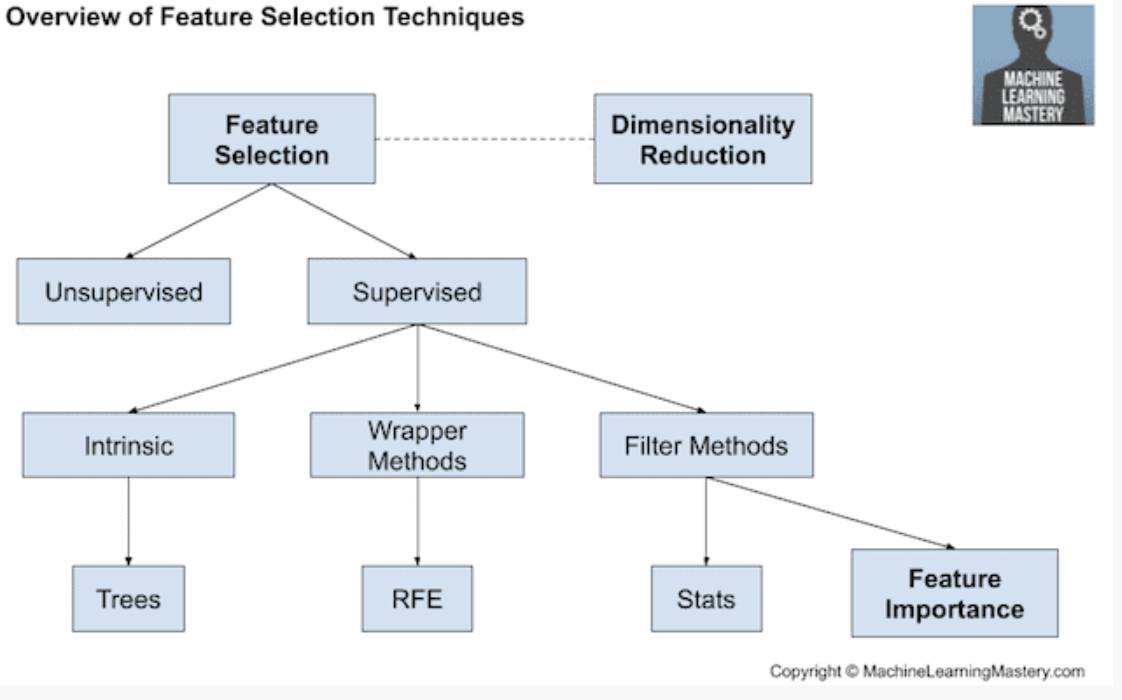

langkah feature selection menggunakan **intrinsic atau Embedded Method** menggunakan algoritma **random forest**

gambar from : https://machinelearningmastery.com/feature-selection-with-real-and-categorical-data/

--------------------------------------------------------------------------
alasan menggunakan embedded dengan random forest karena dapat mengeliminasi fitur penting secara menyeluruh tidak linear

In [ ]:
# menilai fitur terbaik dari hasil encode 95 fitur
rf_selector = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
# melatih model pada data training yang sudah di-encode
rf_selector.fit(X_train_encoded, y_train.astype(int))
# ekstrak skor tingkat kepentingan (Feature Importance)
importances = rf_selector.feature_importances_

# membuat DataFrame dan mengurutkan dari yang paling penting (tertinggi)
feature_importance_df = pd.DataFrame({
    'Nama_Fitur': X_train_encoded.columns,
    'Tingkat_Kepentingan': importances
}).sort_values(by='Tingkat_Kepentingan', ascending=False)

## **Pilih fitur yang akan digunakan**

menggunakan threshold=0.01 karena setelah OHE kolom jadi tambah banyak, nilai data yang tambah tersebut kontribusi dengan model kecil, jadi ambil yang >0.01%

In [ ]:
# buang semua fitur yang kontribusinya kurang dari 1% (0.01)
threshold = 0.01

# filter nama kolom secara otomatis dari hasil dataframe Random Forest
fitur_pemenang_df = feature_importance_df[feature_importance_df['Tingkat_Kepentingan'] >= threshold]
fitur_final_otomatis = fitur_pemenang_df['Nama_Fitur'].tolist()

# split DATASET
X_train_selected = X_train_encoded[fitur_final_otomatis]
X_test_selected = X_test_encoded[fitur_final_otomatis]

#  hasilnya
print(f"=== HASIL SELEKSI FITUR (Threshold >= {threshold}) ===")
print(f"Jumlah fitur yang lolos seleksi: {len(fitur_final_otomatis)} kolom")
print("Daftar Fitur yang Lolos:")
for i, kolom in enumerate(fitur_final_otomatis, 1):
    print(f"{i}. {kolom}")

print(f"\nUkuran X_train final: {X_train_selected.shape}")
print(f"Ukuran X_test final: {X_test_selected.shape}")

=== HASIL SELEKSI FITUR (Threshold >= 0.01) ===
Jumlah fitur yang lolos seleksi: 19 kolom
Daftar Fitur yang Lolos:
1. int_rate
2. grade
3. annual_inc
4. inq_last_6mths
5. dti
6. revol_util
7. installment
8. revol_bal
9. term_months
10. loan_amnt
11. total_acc
12. initial_list_status_w
13. initial_list_status_f
14. open_acc
15. verification_status_verified
16. home_ownership_rent
17. home_ownership_mortgage
18. purpose_small business
19. emp_length_years

Ukuran X_train final: (373004, 19)
Ukuran X_test final: (93252, 19)


# Scaling
 **RobustScaler** untuk menekan semua angka menjadi skala yang setara, mengurangi nilai median dari setiap data lalu membaginya dengan Rentang Antarkuartil (IQR)

In [ ]:
robust_scaler = RobustScaler()
# Fit dan Transform HANYA pada data Training

# mengubah dataframe menjadi format array numpy
X_train_scaled_array = robust_scaler.fit_transform(X_train_selected)

# Transform SAJA pada data Testing (mencegah data leakage)
X_test_scaled_array = robust_scaler.transform(X_test_selected)

# mengembalikan format array menjadi DataFrame agar nama kolomnya tidak hilang
X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=X_train_selected.columns, index=X_train_selected.index)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=X_test_selected.columns, index=X_test_selected.index)

print(X_train_scaled.head())

        int_rate  grade  annual_inc  inq_last_6mths       dti  revol_util  \
234687 -0.994545   -1.0    0.010580             0.0 -0.169877   -0.073239   
265088 -0.121818    0.0   -0.291284             0.0 -0.107706   -0.476056   
325027  0.058182    0.0    0.740826             0.0  0.359019    0.292958   
364648  1.776364    1.5    0.626147             0.0  0.002627    1.152113   
69519   0.116364    0.0   -0.612385             0.0  1.091944    0.315493   

        installment  revol_bal  term_months  loan_amnt  total_acc  \
234687     0.231977   0.195443          0.0   0.200000  -0.466667   
265088    -0.126838   0.262529          1.0   0.250000  -0.533333   
325027    -0.207151   0.823430          1.0   0.133333   1.600000   
364648     1.982138   0.172745          1.0   1.916667  -0.666667   
69519     -0.120325  -0.282785          0.0  -0.166667  -0.333333   

        initial_list_status_w  initial_list_status_f  open_acc  \
234687                    0.0                    0.0 -0.

# Smote
dataset ini imbalancekarena mayoritas nasabah masuk ke dalam kategori Good Loan 89%.

In [ ]:
# komposisi target sebelum SMOTE
print(f"Komposisi target SEBELUM SMOTE: {Counter(y_train)}")

# Inisialisasi SMOTE
smote = SMOTE(random_state=42)

# Fit dan Resample HANYA pada data Training yang sudah di-scale
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train.astype(int))

# komposisi target setelah SMOTE
print(f"Komposisi target SETELAH SMOTE: {Counter(y_train_resampled)}")
print(f"\nUkuran akhir X_train setelah SMOTE: {X_train_resampled.shape}")

Komposisi target SEBELUM SMOTE: Counter({np.int64(0): 332232, np.int64(1): 40772})
Komposisi target SETELAH SMOTE: Counter({0: 332232, 1: 332232})

Ukuran akhir X_train setelah SMOTE: (664464, 19)


# Modeling

## Logistic Regresi

In [ ]:
lr = LogisticRegression(
    random_state=42,
    max_iter=500,
    n_jobs=-1)
lr.fit(X_train_resampled, y_train_resampled)

LogisticRegression(max_iter=500, n_jobs=-1, random_state=42)

In [ ]:
lr_pred = lr.predict(X_test_scaled)
logreg_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]

## Decition Tree

In [ ]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
    )
dt_model.fit(X_train_resampled, y_train_resampled)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [ ]:
dt_pred = dt_model.predict(X_test_scaled)
dt_pred_proba = dt_model.predict_proba(X_test_scaled)[:, 1]

## Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=10,
    n_jobs=-1
    )
rf_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test_scaled)
rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

## Naive Bayes

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train_resampled, y_train_resampled)

GaussianNB()

In [ ]:
nb_pred = nb_model.predict(X_test_scaled)
nb_pred_proba = nb_model.predict_proba(X_test_scaled)[:, 1]

## AdaBoost

In [ ]:
ada_model= AdaBoostClassifier(
    random_state=42,
    n_estimators= 100,
    learning_rate=0.1
)
ada_model.fit(X_train_resampled, y_train_resampled)

AdaBoostClassifier(learning_rate=0.1, n_estimators=100, random_state=42)

In [ ]:
ada_pred = ada_model.predict(X_test_scaled)
ada_pred_proba = ada_model.predict_proba(X_test_scaled)[:, 1]

## XGBoost

In [ ]:
xgboost_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3
)
xgboost_model.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xg_pred = xgboost_model.predict(X_test_scaled)
xg_pred_proba = xgboost_model.predict_proba(X_test_scaled)[:, 1]

# Evaluasi Model

In [ ]:
pred_results = {
   'Logistic Regression': (lr_pred, logreg_pred_proba),
   'Decision Tree': (dt_pred, dt_pred_proba),
   'Random Forest': (rf_pred, rf_model.predict_proba(X_test_scaled)[:, 1]),
   'Naive Bayes': (nb_pred, nb_pred_proba),
   'AdaBoost': (ada_pred, ada_pred_proba),
   'XGBoost': (xg_pred, xg_pred_proba)
}

summary_evaluasi = []

for name, (pred, pred_proba) in pred_results.items():
    report = classification_report(y_test.astype(int), pred, output_dict=True)['1']

    #  list summary
    summary_evaluasi.append({
        'Nama Model': name,
        'Accuracy': accuracy_score(y_test.astype(int), pred),
        'Recall (Bad Loan)': report['recall'],
        'Precision (Bad Loan)': report['precision'],
        'F1-Score (Bad Loan)': report['f1-score'],
        'ROC-AUC': roc_auc_score(y_test.astype(int), pred_proba)
    })
lending_model = pd.DataFrame(summary_evaluasi).sort_values(by='ROC-AUC', ascending=False)

print("=== EVALUASI DAN PERBANDINGAN MODEL ===")
format_desimal = {col: '{:,.2f}'.format for col in lending_model.columns if col != 'Nama Model'}
print(lending_model.to_string(index=False, formatters=format_desimal))

=== EVALUASI DAN PERBANDINGAN MODEL ===
         Nama Model Accuracy Recall (Bad Loan) Precision (Bad Loan) F1-Score (Bad Loan) ROC-AUC
Logistic Regression     0.63              0.63                 0.17                0.27    0.68
      Random Forest     0.71              0.48                 0.19                0.27    0.67
            XGBoost     0.86              0.12                 0.24                0.16    0.66
        Naive Bayes     0.58              0.66                 0.16                0.26    0.66
           AdaBoost     0.58              0.64                 0.16                0.25    0.65
      Decision Tree     0.74              0.39                 0.18                0.25    0.64


**Interpretasi**
note: dataset ini lebih mengutamakan nilai ROC-AUC dan RECALL --> meminimalkan kerugian finansial akibat nasabah gagal bayar (False Negative)

**berdasarkan hasil matrix evaluasi**
--> XGBOOST memang accuracy paling tinggi 0.86, tapi recall(bad_loan) jelek 0.12. alasanya, dataset ini timpang, meskipun sudah dilakukan smote, karakteristik XGBOOST ttp mengejar Accuracy tinggi.

--> **Logistic regression** : model yang akan digunakan sebagai prediksi untuk dataset lending. nilai recall(bad_loan) dan ROC-AUC paling tinggi 0.63 dan 0.68

--> meskipun nilai recall NB dan Adaboost lebih tinggi tapi Accuracynya rendah, artinya NB dan adaboost 58% mengklaim orang tidak bisa bayar pinjaman, pdhl sbnarnya bisa bayar."menuduh orang baik sebagai penipu"



# save model

In [ ]:
joblib.dump(lr,'model_lr.joblib')
joblib.dump(robust_scaler,'robust_scling.joblib')

['robust_scling.joblib']

# Feature Importance
tidak bisa menggunakan fungsi ".feature_importances_" seperti pada random forest.

karena model yang digunakan adalah LR, penentu kekuatan fitur dilihat dari nilai Koefisien, semakin besar (baik + atau -) semakin sensitif model tehdp perubahan fitur

In [ ]:
koefisien = lr.coef_[0]

# DataFrame untuk memetakan nama fitur dan nilai koefisiennya
df_importance_lr = pd.DataFrame({
    'Nama Fitur': X_train_selected.columns,
    'Nilai Koefisien': koefisien,
    'Kekuatan Pengaruh (Absolut)': abs(koefisien)
}).sort_values(by='Kekuatan Pengaruh (Absolut)', ascending=False)

print("\n=== TINGKAT KEPENTINGAN FITUR (LOGISTIC REGRESSION COEFFICIENTS) ===")
print(df_importance_lr[['Nama Fitur', 'Nilai Koefisien']].to_string(index=False))


=== TINGKAT KEPENTINGAN FITUR (LOGISTIC REGRESSION COEFFICIENTS) ===
                  Nama Fitur  Nilai Koefisien
                    int_rate         0.860262
      purpose_small business         0.371608
         home_ownership_rent         0.295102
                       grade        -0.282632
                  annual_inc        -0.247554
                 installment         0.192946
       initial_list_status_w        -0.167326
       initial_list_status_f         0.167326
     home_ownership_mortgage         0.151576
                   loan_amnt        -0.127788
              inq_last_6mths         0.124262
                   total_acc        -0.096674
                         dti         0.091925
                 term_months         0.073506
                  revol_util         0.054095
                    open_acc         0.052766
            emp_length_years        -0.043673
verification_status_verified         0.038108
                   revol_bal        -0.008182


**Interpretasi**
--> koefisien positif : semakin tinggi, peluang debitor gagal bayar juga tinggi.

--- contoh : jika suku bunga (int_rate) naik, maka secara otomatis risiko debitor tersebut untuk mengalami gagal bayar juga akan ikut besar

--> koefisien negatif : semakin tinggi, maka peluang debitur ggal bayar rendah(finansial debitur aman)

--- contoh : Semakin besar pendapatan tahunan (annual_inc) seorang debitor, maka risiko dia untuk gagal bayar justru akan semakin rendah (debitor semakin aman bagi perusahaan)."

## Jika fiturnya berada di urutan paling atas, artinya fitur itulah yang paling sensitif dan paling memengaruhi keputusan model dalam menentukan Good atau Bad Loan.